MEMULAI PEMROSESAN MODEL RANDOM FOREST UNTUK 5 INDEKS VEGETASI

>>> MENGANALISIS INDEKS: NDVI <<<
Metrik Evaluasi untuk Model NDVI:
- Data Pelatihan (n=32): R-Square = 0.4295 | RMSE = 0.1551
- Data Pengujian (n=14): R-Square = 0.1606 | RMSE = 0.1906


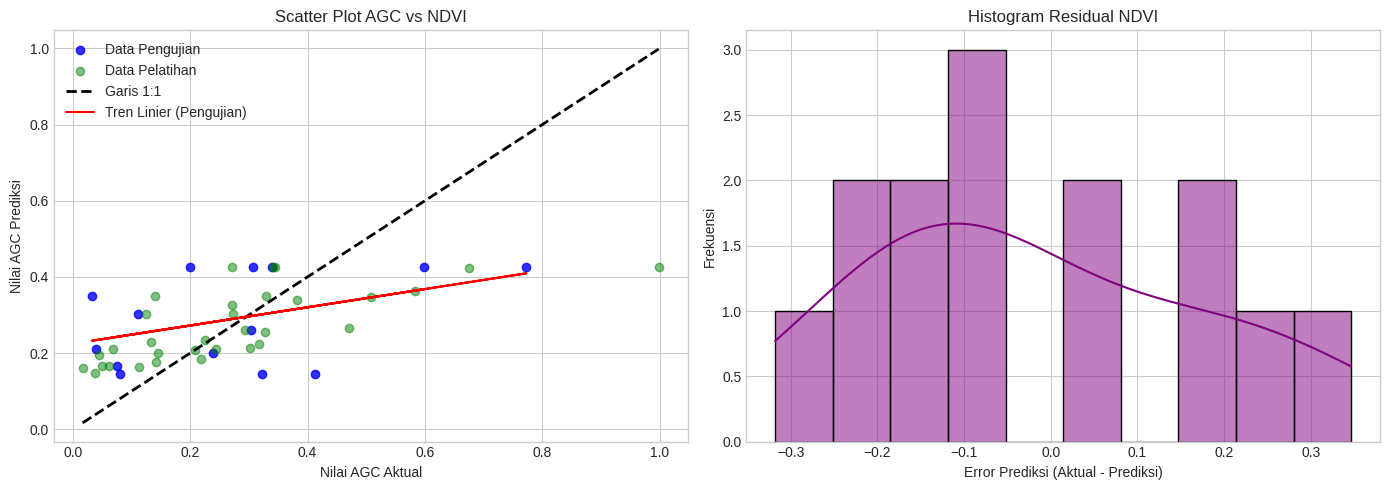

-> Ekspor GIS Selesai: File disimpan sebagai '/content/Prediksi_AGC_NDVI.tif'


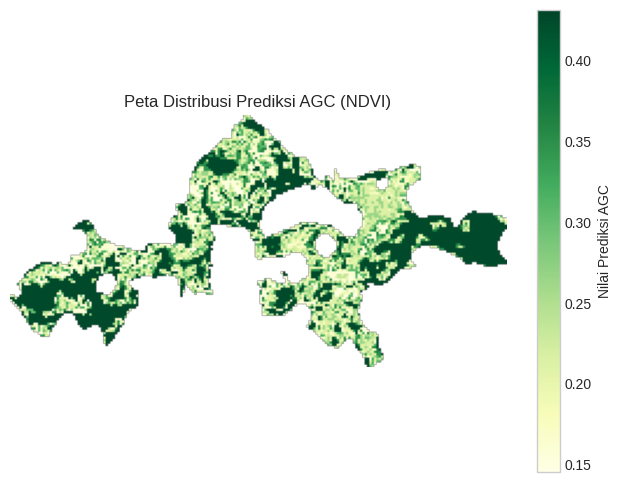


>>> MENGANALISIS INDEKS: EVI <<<
Metrik Evaluasi untuk Model EVI:
- Data Pelatihan (n=32): R-Square = 0.4754 | RMSE = 0.1487
- Data Pengujian (n=14): R-Square = 0.3129 | RMSE = 0.1725


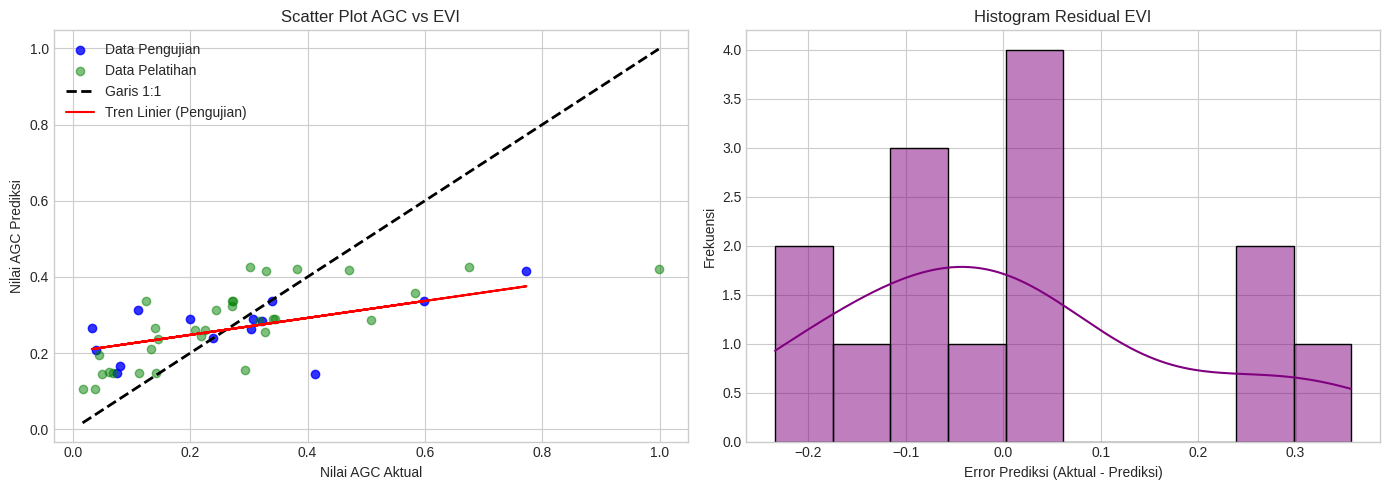

-> Ekspor GIS Selesai: File disimpan sebagai '/content/Prediksi_AGC_EVI.tif'



>>> MENGANALISIS INDEKS: SR <<<
Metrik Evaluasi untuk Model SR:
- Data Pelatihan (n=32): R-Square = 0.4300 | RMSE = 0.1550
- Data Pengujian (n=14): R-Square = 0.1606 | RMSE = 0.1906


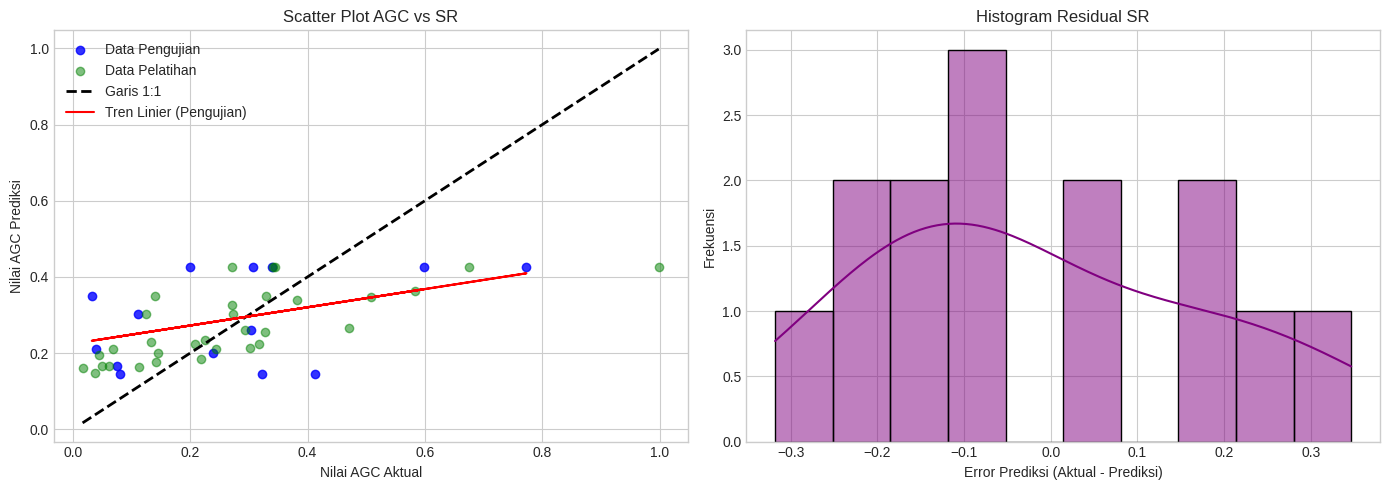

-> Ekspor GIS Selesai: File disimpan sebagai '/content/Prediksi_AGC_SR.tif'



>>> MENGANALISIS INDEKS: DVI <<<
Metrik Evaluasi untuk Model DVI:
- Data Pelatihan (n=32): R-Square = 0.4526 | RMSE = 0.1519
- Data Pengujian (n=14): R-Square = -0.0823 | RMSE = 0.2164


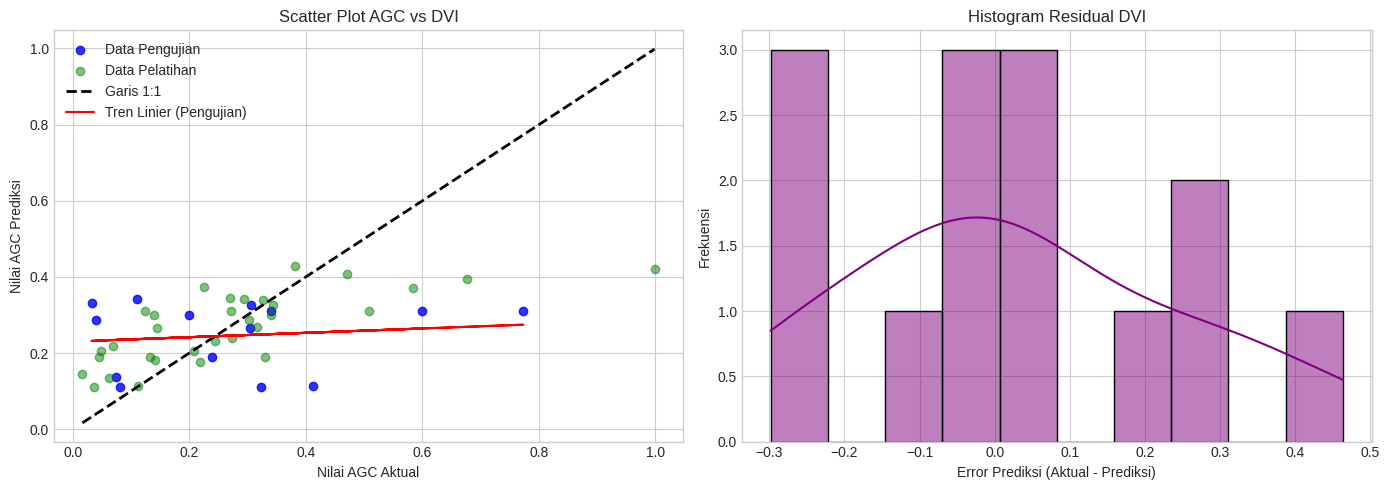

-> Ekspor GIS Selesai: File disimpan sebagai '/content/Prediksi_AGC_DVI.tif'



>>> MENGANALISIS INDEKS: GNDVI <<<
Metrik Evaluasi untuk Model GNDVI:
- Data Pelatihan (n=32): R-Square = 0.4338 | RMSE = 0.1545
- Data Pengujian (n=14): R-Square = -0.0299 | RMSE = 0.2111


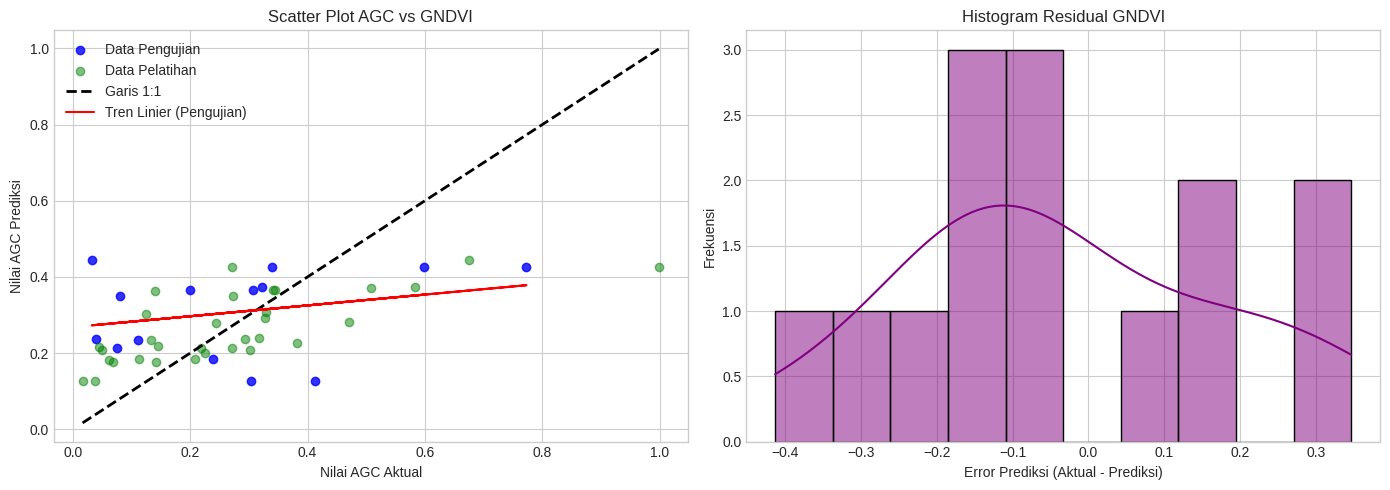

-> Ekspor GIS Selesai: File disimpan sebagai '/content/Prediksi_AGC_GNDVI.tif'


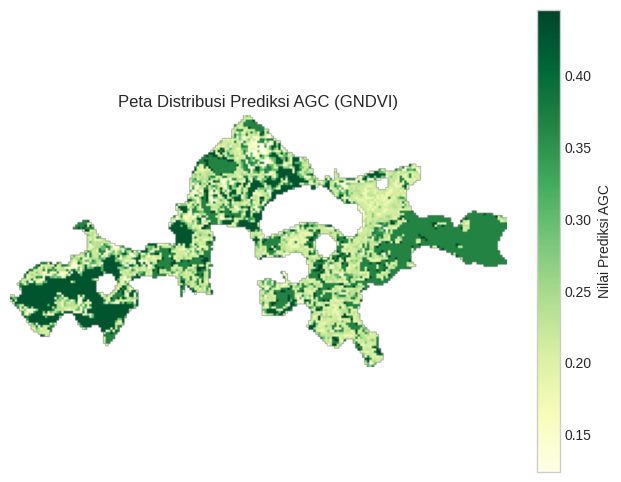

SELURUH PROSES SELESAI.


In [12]:
# ==============================================================================
# PROYEK PENELITIAN: PREDIKSI AGC MENGGUNAKAN RANDOM FOREST (PER INDEKS)
# ==============================================================================

# 1. Impor Pustaka
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings

# Mengabaikan peringatan yang tidak relevan agar output bersih
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Konfigurasi Direktori dan Parameter
# Sesuaikan dengan path di Google Colab Anda
path_csv = "/content/data_RF.csv"
dir_tiff = "/content"

# Daftar indeks yang akan diproses satu per satu (Regresi Sederhana)
fitur_indeks = ['NDVI', 'EVI', 'SR', 'DVI', 'GNDVI']

# Rasio pembagian data (0.30 berarti 70% Pelatihan, 30% Pengujian)
# Dapat diubah menjadi 0.40 (60:40) atau 0.20 (80:20) sesuai kebutuhan eksperimen stakeholder
rasio_pengujian = 0.30

# Membaca dataset tabular
try:
    df = pd.read_csv(path_csv, sep=';')
except FileNotFoundError:
    print(f"Error: File {path_csv} tidak ditemukan. Pastikan file sudah diunggah ke Colab.")
    raise

print("=======================================================================")
print("MEMULAI PEMROSESAN MODEL RANDOM FOREST UNTUK 5 INDEKS VEGETASI")
print("=======================================================================")

# 3. Perulangan Utama (Pemodelan, Evaluasi, dan Pemetaan Spasial per Indeks)
for indeks in fitur_indeks:
    print(f"\n>>> MENGANALISIS INDEKS: {indeks} <<<")

    # --- A. PENYIAPAN DATA ---
    X = df[[indeks]]
    y = df['AGC']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=rasio_pengujian,
        random_state=42 # Mengunci seed agar hasil stabil saat dievaluasi ulang
    )

    # --- B. PEMODELAN RANDOM FOREST ---
    # Konfigurasi Hyperparameter untuk mencegah Overfitting pada data kecil (46 sampel):
    # - n_estimators: 100 (jumlah pohon)
    # - max_depth: 5 (mencegah pohon tumbuh terlalu dalam dan menghafal data)
    # - min_samples_leaf: 2 (memaksa minimal ada 2 sampel di setiap keputusan akhir)
    model_rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42
    )

    model_rf.fit(X_train, y_train)

    # Prediksi untuk evaluasi
    y_pred_train = model_rf.predict(X_train)
    y_pred_test = model_rf.predict(X_test)

    # --- C. EVALUASI METRIK STATISTIK ---
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    print(f"Metrik Evaluasi untuk Model {indeks}:")
    print(f"- Data Pelatihan (n={len(X_train)}): R-Square = {r2_train:.4f} | RMSE = {rmse_train:.4f}")
    print(f"- Data Pengujian (n={len(X_test)}): R-Square = {r2_test:.4f} | RMSE = {rmse_test:.4f}")

    # --- D. VISUALISASI KINERJA (Scatter Plot & Histogram) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Scatter Plot (Aktual vs Prediksi)
    axes[0].scatter(y_test, y_pred_test, color='blue', alpha=0.8, label='Data Pengujian')
    axes[0].scatter(y_train, y_pred_train, color='green', alpha=0.5, label='Data Pelatihan')

    min_val = min(y.min(), min(y_pred_train), min(y_pred_test))
    max_val = max(y.max(), max(y_pred_train), max(y_pred_test))
    axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Garis 1:1')

    # Garis tren untuk data pengujian
    coef = np.polyfit(y_test, y_pred_test, 1)
    poly1d_fn = np.poly1d(coef)
    axes[0].plot(y_test, poly1d_fn(y_test), '-r', label='Tren Linier (Pengujian)')

    axes[0].set_xlabel('Nilai AGC Aktual')
    axes[0].set_ylabel('Nilai AGC Prediksi')
    axes[0].set_title(f'Scatter Plot AGC vs {indeks}')
    axes[0].legend()

    # Plot 2: Histogram Residual
    residual = y_test - y_pred_test
    sns.histplot(residual, bins=10, kde=True, ax=axes[1], color='purple')
    axes[1].set_xlabel('Error Prediksi (Aktual - Prediksi)')
    axes[1].set_ylabel('Frekuensi')
    axes[1].set_title(f'Histogram Residual {indeks}')

    plt.tight_layout()
    plt.show()

    # --- E. PREDIKSI SPASIAL DAN EKSPOR GEOTIFF ---
    input_tiff_path = f"{dir_tiff}/{indeks}_Float_Clip.tif"
    output_tiff_path = f"{dir_tiff}/Prediksi_AGC_{indeks}.tif"

    if os.path.exists(input_tiff_path):
        with rasterio.open(input_tiff_path) as src:
            profile = src.profile.copy()
            array_data = src.read(1)

        rows, cols = array_data.shape
        raster_1d = array_data.flatten().reshape(-1, 1)

        # Masking untuk mengabaikan nilai NaN dan NoData
        nodata_val = profile.get('nodata', -9999)
        mask_valid = ~np.isnan(raster_1d).flatten() & (raster_1d.flatten() != nodata_val)

        prediksi_1d = np.full(rows * cols, np.nan)

        if np.any(mask_valid):
            prediksi_1d[mask_valid] = model_rf.predict(raster_1d[mask_valid])

        agc_map = prediksi_1d.reshape(rows, cols)

        # Membersihkan metadata yang menyebabkan peringatan "BLOCKXSIZE / TILED"
        profile.pop('blockxsize', None)
        profile.pop('blockysize', None)
        profile.pop('tiled', None)

        # Memperbarui profil untuk output regresi
        profile.update(
            dtype=rasterio.float32,
            count=1,
            nodata=np.nan
        )

        with rasterio.open(output_tiff_path, 'w', **profile) as dst:
            dst.write(agc_map.astype(rasterio.float32), 1)

        print(f"-> Ekspor GIS Selesai: File disimpan sebagai '{output_tiff_path}'")

        # Plot Pratinjau Peta
        plt.figure(figsize=(8, 6))
        plt.imshow(agc_map, cmap='YlGn')
        plt.colorbar(label='Nilai Prediksi AGC')
        plt.title(f'Peta Distribusi Prediksi AGC ({indeks})')
        plt.axis('off')
        plt.show()

    else:
        print(f"-> GAGAL EKSPOR: File citra mentah '{input_tiff_path}' tidak ditemukan di {dir_tiff}.")

print("=======================================================================")
print("SELURUH PROSES SELESAI.")

In [ ]:
# === AUTO-GENERATED THUMBNAIL EXPORT ===
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os

# Find all existing figure axes
figures = [plt.figure(i) for i in plt.get_fignums()]
if figures:
    fig = figures[-1]  # Use last figure
else:
    # Create a summary figure from available data
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.text(0.5, 0.5, 'Project Visualization', fontsize=24, 
            ha='center', va='center', transform=ax.transAxes,
            fontweight='bold', color='#2d3436')
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('#f8f9fa')
    ax.axis('off')

thumbnail_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'thumbnail.png')
fig.savefig(thumbnail_path, dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print(f"✅ Thumbnail saved: {thumbnail_path}")
plt.show()
